# Esercitazione 12
12 Maggio 2026

### Codici per l'interpolazione polinomiale nella forma di Lagrange 

Scrivere la function **interpL** che calcoli
il polinomio interpolante in forma di Lagrange  
Tale function deve assumere come dati in input:
 
 - x vettore dei nodi di interpolazione,
- y vettore dei valori della funzione nei nodi di interpolazione,
- xx vettore dei punti in cui si vuole valutare il polinomio interpolante.
 
In output deve essere restituito yy vettore contenente i valori assunti dal polinomio interpolante.

 
Funzioni Python  utili:
 
-  numpy.poly() restituisce i coefficienti di un polinomio di zeri assegnati,
 - numpy.polyval(p, x)  valuta un polinomio in un punto assegnato.

In [1]:
import numpy as np

In [2]:
def plagr(xnodi, j):
    x_zeri = np.zeros_like(xnodi)
    n = xnodi.size

    if j == 0:
        x_zeri = xnodi[1:n]
    else:
        x_zeri = np.append(xnodi[0:j], xnodi[j+1:n])

    num = np.poly(x_zeri)
    den = np.polyval(num, xnodi[j])

    p = num / den
    return p

In [10]:
def interpl(x, y, xval):
    n = x.size
    m = xval.size

    L = np.zeros((m, n))

    for j in range(n):
        p = plagr(x, j)
        #Colonna j-esima della matrice L, che contiene il polinomio di base di Lagrange j-esimo valutato in xval
        L[:, j] = np.polyval(p, xval)

        polL = L@y

    return polL

In [11]:
import matplotlib.pyplot as plt

## Esercizio 1

Realizzare uno script che calcoli nella forma di Lagrange i polinomi che
interpolano le funzioni test $\sin(x)$ e $\cos(x)$ nei punti $x_k = k \pi/2$, con
$k = 0, 1, 2, 3, 4$. Visualizzare graficamente i polinomi ottenuti insieme
alle funzioni assegnate.

In [12]:
x = np.arange(0, 2*np.pi+0.1, np.pi/2)
y = np.sin(x)

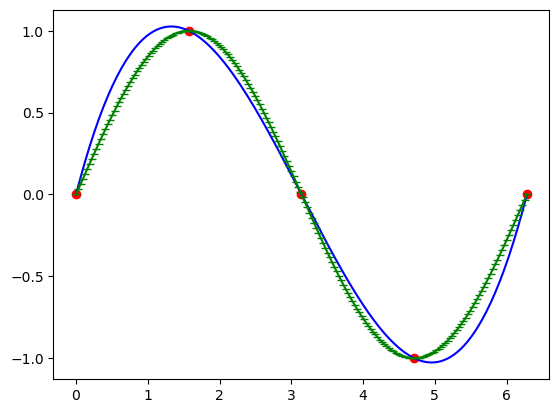

In [14]:
xval = np.linspace(np.min(x), np.max(x), 200)
polL = interpl(x, y, xval)
plt.plot(x, y, 'ro', xval, polL, 'b', xval, np.sin(xval), 'g-_')

## Esercizio 2
Realizzare uno script python che interpola le coppie $x_i,y_i$, $i=0,\cdots,3$
dove $x_i,i=0,3$ sono punti equidistanti nell' intervallo [-1,1] e $y_i=f(x_i)$ dove $f(x)=3x^3+2x^2+2x-1$ 
Giustificare i risultati ottenuti.

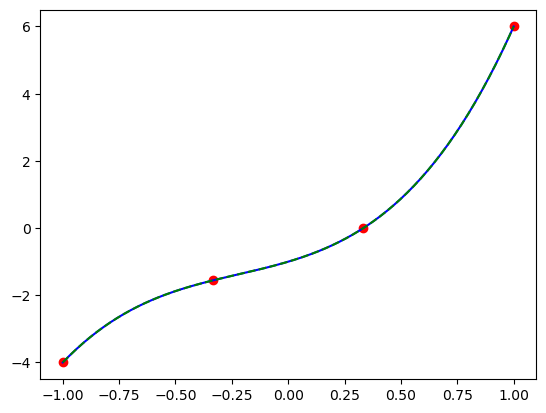

In [19]:
x2 = np.linspace(-1.0, 1.0, 4)
f = lambda x : 3 * x**3 + 2 * x**2 + 2 * x - 1
y2 = f(x2)
xval2 = np.linspace(-1, 1, 200)
polL2 = interpl(x2, y2, xval2)
plt.plot(x2, y2, 'ro', xval2, polL2, 'b', xval2, f(xval2), 'g--')

## Esercizio 3
La temperatura $T$ in  prossimità  del suolo  subisce una variazione dipendente dalla latitudine $L$ 
L=np.array([-55, -45, -35, -25, -15, -5, 5, 15, 25, 35, 45, 55, 65])
T=np.array([3.7, 3.7,3.52,3.27, 3.2, 3.15, 3.15, 3.25, 3.47, 3.52, 3.65, 3.67, 3.52])


 
- Si vuole costruire un modello che descriva la legge $T = T(L)$ anche per latitudini non misurate. A tal fine si scriva uno script che fornisca la variazione di temperatura alle latitudini $L = \pm 42$ utilizzando il polinomio interpolante. Visualizzare in un grafico i dati assegnati, il polinomio interpolante e le stime di $T$ ottenute per $L = \pm 42$.


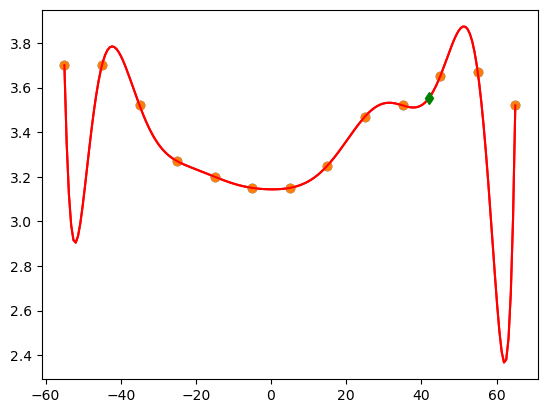

In [24]:
L=np.array([-55.0, -45, -35, -25, -15, -5, 5, 15, 25, 35, 45, 55, 65])
T=np.array([3.7, 3.7,3.52,3.27, 3.2, 3.15, 3.15, 3.25, 3.47, 3.52, 3.65, 3.67, 3.52])
xval3 = np.linspace(np.min(L), np.max(L), 200)
polL3 = interpl(L, T, xval3)

plt.plot(L, T, 'o', xval3, polL3, '-r')
L42 = np.array([42.0])
T42 = interpl(L, T, L42)

plt.plot(L, T, 'o', xval3, polL3, '-r', L42, T42, 'dg-')

## Esercizio 4

Scrivere uno script che calcoli il polinomio interpolante un insieme di punti $P_i =(x_i, y_i)$ $i = 0, ..., n $ nella forma di Lagrange con $x_i$ scelti dall'utente come:
    - punti equidistanti in un intervallo $[a, b]$,
    - punti definiti dai nodi di Chebyshev nell'intervallo $[a, b]$, ossia
$$
x_i = \frac{(a + b)}{2}+\frac{(b-a)}{2} \, \cos \left(
\frac{(2i+1)\pi}{2(n + 1)}
\right), \quad  i =0, ..., n 
$$
 
  e $y_i = f(x_i)$ ottenuti dalla valutazione nei punti $x_i$ di una funzione test   $f: \ [a, b] \rightarrow {\mathbb R}$. Testare lo script sulle funzioni
 
  - $f(x) = \sin(x)-2 \sin(2x)$,   $ \quad x \in [-\pi,\pi]$,
  -  $f(x) = \sinh(x)$, $ \quad  x \in [-2, 2]$,
  - $f(x) = |x|$,  $ \quad x \in [-1, 1]$,
  - $f(x) = 1/(1+25*x^2)$,  $ \quad x \in [-1, 1]$ (funzione di Runge).

Calcolare l'errore di interpolazione $r(x) = f(x)-p(x)$,
tra la funzione test $f(x)$ e il polinomio di interpolazione $p(x)$.
Visualizzare il grafico di $f(x)$ e $p(x)$, ed il grafico di
$|r(x)|$. Cosa si osserva? Cosa accade all'aumentare del grado $n$ di $p(x)$?
(Si costruisca una tabella che riporti i valori di $\|r(x)\|_{\infty}$ al variare di $n$).


In [27]:
def zeri_cheb(a, b, n):
    t1 = (a + b) / 2
    t2 = (b - a) / 2
    x = np.zeros((n+1,))
    for k in range(n+1):
        x[k] = t1 + t2 * np.cos(((2 * k+1) / (2 * n+1)) * np.pi)
    return x

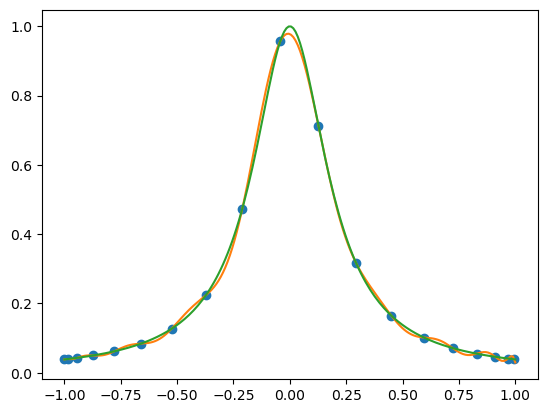

In [31]:
n = 18
x_cheb = zeri_cheb(-1, 1, n)
f4 = lambda x: 1 / (1 + 25 * x**2)
y4 = f4(x_cheb)
xval4= np.linspace(-1, 1, 200)
polCheb = interpl(x_cheb, y4, xval4)
plt.plot(x_cheb, y4, 'o', xval4, polCheb, xval4, f4(xval4))

## Esercizio 5

Per $n = 5, 10, 15, 20$ fornire un'approssimazione della costante di Lebesgue
scegliendo $x_1, x_2, ..., x_{n+1}$ equispaziati in $[-1, 1]$ oppure coincidenti con
i nodi di Chebyshev $x_i = \cos \left(\frac{(2i-1)\pi}{2(n + 1)}  \right)$, $i =1, ..., n + 1$.

## Esercizio 6

Si interpolino mediante il polinomio $p_{21}(x)$ i 22 punti $(x_i, y_i)$ con $x_i$ equispaziati in $[-1, 1]$ e $y_i = \sin(2 \pi x_i)$. Si considerino poi le ordinate $\tilde{y}_i = y_i + \varepsilon_i$, dove $\varepsilon_i$ denota l'$i$-esima componente del vettore $0.0002*np.random.random(22,)$, e si calcoli il corrispondente
polinomio interpolante $\tilde{p}_{21}(x)$. Si visualizzino e si commentino
i risultati ottenuti, calcolando anche l'errore relativo sul polinomio interpolante
e sui dati.
